<a href="https://colab.research.google.com/github/SUBASHMURALI/SalesReportWithGoogleColab/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Upload File Into Notebook
from google.colab import files
uploaded = files.upload()

Saving SuperStore_Sales_Dataset.csv to SuperStore_Sales_Dataset.csv


In [ ]:
# Import File Using Pandas
import pandas as pd
df = pd.read_csv("SuperStore_Sales_Dataset.csv")

In [ ]:
# Showing All_Rows, All_Columns Of The DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
# Droping Column In Tables
drop_columns = df.drop(["Returns", "ind1", "ind2"], axis=1, inplace=True)

In [ ]:
# Rename Column Name In Dataset
df.rename(columns={"Row ID+O6G3A1:R6" : "Row_ID", "Order ID" : "Order_ID", "Order Date" : "Order_Date",
                   "Ship Date" : "Ship_Date",	"Ship Mode" : "Ship_Mode",	"Customer ID" : "Customer_ID",
                   "Customer Name" : "Customer_Name",	"Segment" :"Segment",	"Country" :"Country",
                   "City" : "City","State" : "State",	"Region" : "Region",	"Product ID" : "Product_ID",
                   "Category" : "Category",	"Sub-Category" : "Sub_cateogry",
                   "Product Name" : "Product_Name","Sales" : "Sales", "Quantity" : "Quantity",
                   "Profit" : "Profit", "Payment Mode" : "Payment_Mode"},
          inplace=True)

In [ ]:
# Taking Copy Of Table
df1 = df.copy()

In [ ]:
# Droping Column In Tables
drop_columns = df1.drop(["Returns", "ind1", "ind2"], axis=1, inplace=True)

In [ ]:
# Total counts Of Rows And Columns
df1.shape

(5901, 20)

In [ ]:
# Column Names
df1.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product_ID', 'Category', 'Sub_cateogry', 'Product_Name',
       'Sales', 'Quantity', 'Profit', 'Payment_Mode'],
      dtype='object')

In [ ]:
# Finding data Type In DateFrame
df1.dtypes

,0
Row_ID,int64
Order_ID,object
Order_Date,object
Ship_Date,object
Ship_Mode,object
Customer_ID,object
Customer_Name,object
Segment,object
Country,object
City,object


In [ ]:
# Calling Table First Five Rows
df1.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub_cateogry,Product_Name,Sales,Quantity,Profit,Payment_Mode
0,4918,CA-2019-160304,01-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Cherry Finish",73.94,1,28.2668,Online
1,4919,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Cherry Finish",173.94,3,38.2668,Online
2,4920,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.2742,Cards
3,3074,CA-2019-125206,03-01-2019,05-01-2019,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File Folders,114.46,2,28.6150,Online
4,8604,US-2019-116365,03-01-2019,08-01-2019,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,Online


In [ ]:
# Checking Duplicates Values For Wohle Table
a = df1.duplicated(subset=[
    'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
    'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City',
    'State', 'Region', 'Product_ID', 'Category', 'Sub_cateogry',
    'Product_Name', 'Sales', 'Quantity', 'Profit', 'Payment_Mode'
])
a.value_counts()

,count
False,5901


In [ ]:
# Checking Duplicates Values For Single Column
b = df1['Customer_ID'].duplicated()
b.value_counts()

,count
Customer_ID,
True,5128
False,773


In [ ]:
# Checking Total Values By Category
df1['Category'].value_counts()

,count
Category,
Office Supplies,3569
Furniture,1249
Technology,1083


In [ ]:
# Checking Total Values By Sub_Cateogry
df1['Sub_cateogry'].value_counts()

,count
Sub_cateogry,
Binders,915
Paper,825
Furnishings,573
Phones,519
Storage,498
Art,465
Accessories,461
Chairs,355
Appliances,279


In [ ]:
# Checking Total Values By Region
df1['Region'].value_counts()

,count
Region,
West,1901
East,1688
Central,1381
South,931


In [ ]:
# Checking Total Values By Payment_Mode
df1['Payment_Mode'].value_counts()

,count
Payment_Mode,
COD,2453
Online,2164
Cards,1284


In [ ]:
# Checking Total Values By Segment
df1['Segment'].value_counts()

,count
Segment,
Consumer,2997
Corporate,1774
Home Office,1130


In [ ]:
# Region-wise Category Quantity Summary
region_category_Quantity = df1.groupby(["Region", "Category"])["Quantity"].sum().unstack()

region_category_Quantity

Category,Furniture,Office Supplies,Technology
Region,,,
Central,1057,3277,905
East,1290,3774,1187
South,726,2190,613
West,1558,4384,1356


In [ ]:
# Region-wise Category Sales Summary
region_category_sales = df1.groupby(["Region", "Category"])["Sales"].sum().unstack()

region_category_sales

Category,Furniture,Office Supplies,Technology
Region,,,
Central,105505.4532,150154.353,85347.718
East,117071.9730,189066.821,144095.872
South,72984.8670,99652.140,79484.074
West,155946.3520,204834.373,161660.327


In [ ]:
# Region-wise Category Profit Summary
region_category_profit = df.groupby(["Region", "Category"])["Profit"].sum().unstack()

region_category_profit

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-1534.7880,6477.6297,22507.1654
East,3621.5039,23248.6104,26530.3100
South,2562.0203,11104.9759,12884.7201
West,5357.8750,33966.0301,28536.0531


In [ ]:
# Sales Summary By Region, Category, And Sub_Category
region_category_sales1 = df.groupby(["Region" ,"Category", "Sub_cateogry"])["Sales"].sum()

region_category_sales1

Region   Category         Sub_cateogry
Central  Furniture        Bookcases       13868.4172
                          Chairs          45825.0890
                          Furnishings     21668.7140
                          Tables          24143.2330
         Office Supplies  Appliances      19738.3190
                          Art             12449.2260
                          Binders         43349.7760
                          Envelopes        3661.3280
                          Fasteners        3175.6040
                          Labels           3317.4920
                          Paper           22207.8880
                          Storage         31931.2520
                          Supplies        10323.4680
         Technology       Accessories     28971.8780
                          Copiers          4249.8780
                          Machines         8778.3540
                          Phones          43347.6080
East     Furniture        Bookcases       14032.3830
                          Chairs          55788.1430
                          Furnishings     28906.1500
                          Tables          18345.2970
         Office Supplies  Appliances      23900.0120
                          Art             12715.1960
                          Binders         52883.6890
                          Envelopes        4232.4120
                          Fasteners        3189.1520
                          Labels           6186.5300
                          Paper           30326.7760
                          Storage         45396.1160
                          Supplies        10236.9380
         Technology       Accessories     25074.1680
                          Copiers         21306.6400
                          Machines        37487.1380
                          Phones          60227.9260
South    Furniture        Bookcases        9250.4900
                          Chairs          23281.4300
                          Furnishings     14300.3740
                          Tables          26152.5730
         Office Supplies  Appliances      15035.2640
                          Art              8177.1720
                          Binders         22183.5780
                          Envelopes        3496.6480
                          Fasteners        1408.1160
                          Labels           2726.0940
                          Paper           16008.1560
                          Storage         25580.8280
                          Supplies         5036.2840
         Technology       Accessories     21188.9300
                          Copiers          8014.8020
                          Machines        14768.2500
                          Phones          35512.0920
West     Furniture        Bookcases       20426.3960
                          Chairs          57051.3360
                          Furnishings     27815.9800
                          Tables          50652.6400
         Office Supplies  Appliances      21631.6520
                          Art             17421.3820
                          Binders         56561.3470
                          Envelopes        5152.0760
                          Fasteners        7432.3660
                          Labels           7167.3400
                          Paper           30910.7920
                          Storage         47433.1220
                          Supplies        11124.2960
         Technology       Accessories     47066.1100
                          Copiers         26164.4780
                          Machines        30953.8190
                          Phones          57475.9200
Name: Sales, dtype: float64

In [ ]:
# Quantity Summary By Region, Category, And Sub_Category
region_category_quantity1 = df1.groupby(["Region" ,"Category", "Sub_cateogry"])["Quantity"].sum()

region_category_quantity1

Region   Category         Sub_cateogry
Central  Furniture        Bookcases        111
                          Chairs           334
                          Furnishings      454
                          Tables           158
         Office Supplies  Appliances       282
                          Art              456
                          Binders          885
                          Envelopes         93
                          Fasteners        141
                          Labels           178
                          Paper            769
                          Storage          407
                          Supplies          66
         Technology       Accessories      429
                          Copiers           14
                          Machines          25
                          Phones           437
East     Furniture        Bookcases        112
                          Chairs           376
                          Furnishings      662
                          Tables           140
         Office Supplies  Appliances       275
                          Art              497
                          Binders          948
                          Envelopes        125
                          Fasteners        190
                          Labels           246
                          Paper            806
                          Storage          545
                          Supplies         142
         Technology       Accessories      451
                          Copiers           46
                          Machines          95
                          Phones           595
South    Furniture        Bookcases         84
                          Chairs           151
                          Furnishings      343
                          Tables           148
         Office Supplies  Appliances       190
                          Art              314
                          Binders          575
                          Envelopes        106
                          Fasteners         54
                          Labels           104
                          Paper            494
                          Storage          292
                          Supplies          61
         Technology       Accessories      266
                          Copiers           21
                          Machines          34
                          Phones           292
West     Furniture        Bookcases        167
                          Chairs           427
                          Furnishings      674
                          Tables           290
         Office Supplies  Appliances       303
                          Art              512
                          Binders         1262
                          Envelopes        139
                          Fasteners        155
                          Labels           283
                          Paper           1005
                          Storage          586
                          Supplies         139
         Technology       Accessories      615
                          Copiers           61
                          Machines          96
                          Phones           584
Name: Quantity, dtype: int64

In [ ]:
# Profit Summary By Region, Category, And Sub_Category
region_category_profit1 = df1.groupby(["Region" ,"Category", "Sub_cateogry"])["Profit"].sum()

region_category_profit1

Region   Category         Sub_cateogry
Central  Furniture        Bookcases        -979.0662
                          Chairs           4216.5126
                          Furnishings     -2902.0089
                          Tables          -1870.2255
         Office Supplies  Appliances         65.3110
                          Art               759.2470
                          Binders         -1037.8059
                          Envelopes         859.7273
                          Fasteners         195.4569
                          Labels            464.7931
                          Paper            4676.9507
                          Storage          1187.9814
                          Supplies         -694.0318
         Technology       Accessories      4829.3214
                          Copiers          9413.9555
                          Machines          729.0346
                          Phones           7534.8539
East     Furniture        Bookcases         273.6452
                          Chairs           4159.5850
                          Furnishings      4399.9522
                          Tables          -5211.6785
         Office Supplies  Appliances       5128.8507
                          Art              1166.6380
                          Binders          5363.4892
                          Envelopes         924.0538
                          Fasteners         181.4057
                          Labels            691.0149
                          Paper            5457.4546
                          Storage          5344.8070
                          Supplies        -1009.1035
         Technology       Accessories      4619.3695
                          Copiers         14716.8864
                          Machines         1608.1376
                          Phones           5585.9165
South    Furniture        Bookcases        1067.1656
                          Chairs           3207.1477
                          Furnishings      1847.3786
                          Tables          -3559.6716
         Office Supplies  Appliances       2671.4569
                          Art               631.4830
                          Binders          1023.9990
                          Envelopes         735.7496
                          Fasteners          77.0229
                          Labels            336.9719
                          Paper            3659.5638
                          Storage          2080.1178
                          Supplies         -111.3890
         Technology       Accessories      4490.7797
                          Copiers          3253.9202
                          Machines          400.4936
                          Phones           4739.5266
West     Furniture        Bookcases        -704.6329
                          Chairs           1823.4579
                          Furnishings      4689.1109
                          Tables           -450.0609
         Office Supplies  Appliances       5300.9912
                          Art              1078.5577
                          Binders         12535.6936
                          Envelopes         988.9766
                          Fasteners         144.5320
                          Labels           1444.4413
                          Paper            7318.4088
                          Storage          4994.1813
                          Supplies          160.2476
         Technology       Accessories     11397.1749
                          Copiers         15389.8207
                          Machines        -2699.5634
                          Phones           4448.6209
Name: Profit, dtype: float64

In [ ]:
# Total Amount Of Sales
df1['Sales'].sum()

np.float64(1565804.3232)

In [ ]:
# Total Amount Of Quantity
df1['Quantity'].sum()

np.int64(22317)

In [ ]:
# Total Amount Of Profit
df1['Profit'].sum()

np.float64(175262.1059)

In [ ]:
# USING INFORMATION CONVATE INTO CHARTS.
# Import Matplotlib For Charts
import matplotlib.pyplot as plt

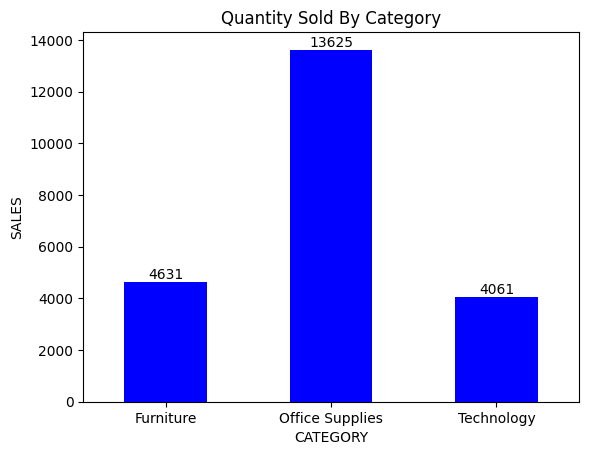

In [ ]:
# CHART 1 :- BAR CHART

# 1. Grouping Data By Category
qty_category = df.groupby("Category")["Quantity"].sum()

# 2. Plotting
a1 = qty_category.plot(kind="bar", color="blue")
plt.title("Quantity Sold By Category")
plt.xlabel("CATEGORY")
plt.ylabel("SALES")
plt.xticks(rotation=360)

# 3. Add Data Labels
for container in a1.containers:
   a1.bar_label(container)

# 4. Output
plt.show()

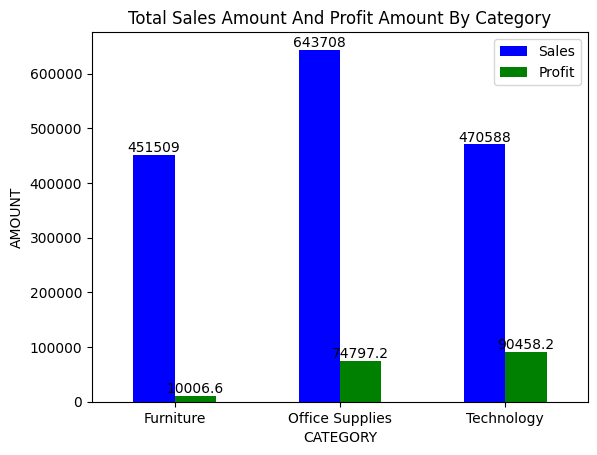

In [ ]:
# CHART 2:- CLUSTER BAR CHART

# 1. Grouping Data By Category
category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum()

# 2. Plotting
ax = category_analysis.plot(kind="bar", color=["blue", "green"])
plt.title("Total Sales Amount And Profit Amount By Category")
plt.xlabel("CATEGORY")
plt.ylabel("AMOUNT")
plt.xticks(rotation=360)

# 3. Add Data Labels
for container in ax.containers:
    ax.bar_label(container)

# 4. Output
plt.show()

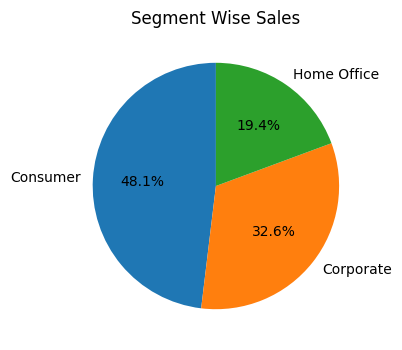

In [ ]:
# CHART 3 :- PIE CHART

# 1. Group Sales By Segment
segment_sales = df.groupby("Segment")["Sales"].sum()

# 2. Create Pie Chart
plt.figure(figsize=(6,  4))
plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

# 3. Adding Title For Chart
plt.title("Segment Wise Sales")

# 4. Output
plt.show()

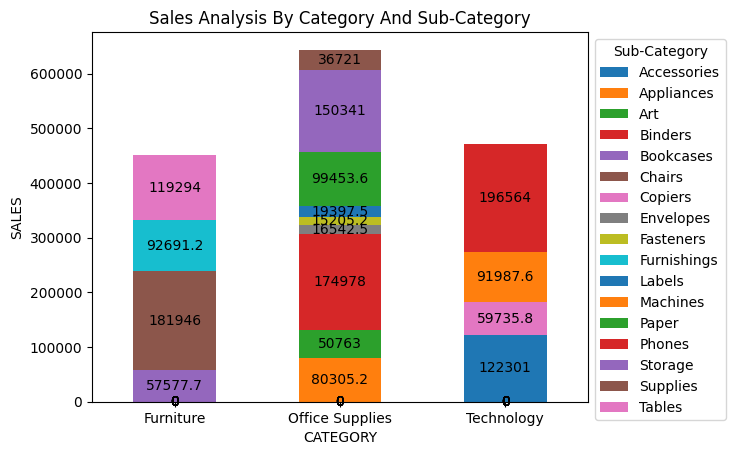

In [ ]:
# CHART 4 :- STACKED BAR
# 1. Grouping Data By Category
stack_data = df.groupby(["Category", "Sub_cateogry"])["Sales"].sum().unstack()

# 2. Plotting
ax = stack_data.plot(kind="bar", stacked=True)
plt.title("Sales Analysis By Category And Sub-Category")
plt.xlabel("CATEGORY")
plt.ylabel("SALES")
plt.xticks(rotation=360)

# 3. Add Data Labels
for container in ax.containers:
    ax.bar_label(container, label_type="center")

# 4. Adding Ledger In Chart
plt.legend(title="Sub-Category", bbox_to_anchor=(1,1), loc="upper left")

# 5. Output
plt.show()

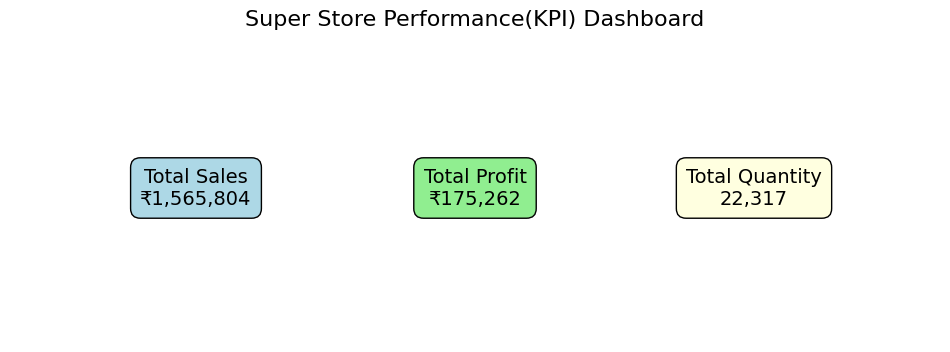

In [ ]:
# CHART 5:- KPI DASHBOARDS

# 1. KPI Calculations
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()

# 2. Create Figure Size
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# 3. Total Sales Card
ax.text( # ax is the Matplotlib axis object, .text() is used to display text on the plot
    0.2, 0.5,  # X-coordinate (20% from the left), Y-coordinate (center vertically)
    f"Total Sales\n₹{total_sales:,.0f}", # f"" is used to insert variable values, Total Sales is the heading, \n creates a new line, ₹{total_sales:,.0f} displays the sales amount
    ha='center', va='center', # ha = Horizontal Alignment, va = Vertical Alignment
    fontsize=14, # Sets text size to 14
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue') # round gives rounded corners, pad=0.5 adds padding inside the box, Sets the box background color
)

# 4. Total Profit Card
ax.text(
    0.5, 0.5,
    f"Total Profit\n₹{total_profit:,.0f}",
    ha='center', va='center',
    fontsize=14,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen')
)

# 5. Total Quantity Card
ax.text(
    0.8, 0.5,
    f"Total Quantity\n{total_quantity:,.0f}",
    ha='center', va='center',
    fontsize=14,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow')
)

# 6. Adding Title For Chart
plt.title("Super Store Performance(KPI) Dashboard", fontsize=16)

# 7. Output
plt.show()